# Multi-bin Fisher forecast for $\Lambda$CDM with Alcock-Paczyński effect

Combined Fisher forecast over 7 PFS redshift bins using `jax.jacfwd`
and a Gaussian covariance for $P^\ell_{\mathrm{1-loop}}(k)$ where $\ell=[0,2,4]$,
including the **Alcock-Paczyński** effect.

Neutrino mass is **fixed** at $m_\nu = 0.06\,$eV (not varied).

| Bin | $z_{\rm mid}$ | $V$ [(Gpc/$h$)$^3$] | $k_{\rm nl}$ [$h$/Mpc] | $\bar{n}$ [($h$/Mpc)$^3$] |
|-----|---------|------|---------|----------|
| 1   | 0.7     | 0.59 | 0.52    | 3.06e-4  |
| 2   | 0.9     | 0.79 | 0.65    | 9.61e-4  |
| 3   | 1.1     | 0.96 | 0.82    | 9.75e-4  |
| 4   | 1.3     | 1.09 | 1.02    | 6.54e-4  |
| 5   | 1.5     | 1.19 | 1.29    | 3.40e-4  |
| 6   | 1.8     | 2.58 | 1.82    | 2.02e-4  |
| 7   | 2.2     | 2.71 | 2.88    | 3.51e-4  |

## Modules

In [1]:
import os

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

from matplotlib.ticker import MultipleLocator, FormatStrFormatter
import matplotlib.lines as mlines

import numdifftools as nd
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.scipy as jsp

### background cosmology

from ps_1loop_jax import background as bg

### jaxptpolypol

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_pk_params,
    unpack_pk_params,
)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import (fisher_matrix, marginalize_fisher,
                                     sigma_from_fisher, fixed_and_varied_indices,
                                     gaussian_prior_fisher, build_prior_sigmas)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian, triangle_plot
from jaxptpolypol.theory import make_pk_ell_fn, compute_fiducial_distances
from jaxptpolypol.bao import load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Emulator and model classes

## Initialize emulators and model

In [2]:
model_path = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=model_path)
print("Emulator input parameters:", pklin_emulator.parameters)

ps1loop_model = PS1LoopModel(do_irres=True)
print("1-loop Pk terms:", ps1loop_model.pk_terms)

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Emulator input parameters: ['ombh2' 'omch2' 'logA' 'ns' 'h' 'z' 'A_b' 'eta_b' 'logT_AGN']


1-loop Pk terms: ['22_dd', '13_dd', 'I_d2', 'I_G2', 'I_d2_d2', 'I_G2_G2', 'I_d2_G2', 'F_G2']


## Cosmology and survey parameter classes

## Fiducial cosmology

In [3]:
cosmo_dict = {
    'ombh2':    0.02242,
    'omch2':    0.11933,
    'logA':     3.047,
    'ns':       0.9665,
    'h':        0.6766,
    'z':        0.7,       # placeholder; overridden per bin in the wrapper
    'A_b':      3.13,
    'eta_b':    0.603,
    'logT_AGN': 7.8,
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  logA: 3.047
  ns: 0.9665
  h: 0.6766
  z: 0.7
  A_b: 3.13
  eta_b: 0.603
  logT_AGN: 7.8


## Survey specifications per bin

In [4]:
# PFS redshift bins
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))  # [Mpc/h]^3
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)  # [h/Mpc]
n_bins   = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)  # [h/Mpc]^3
n_zbins  = len(z_bins)

print(f"Number of redshift bins: {n_zbins}")
for i, (z, V, knl, nd) in enumerate(zip(z_bins, V_bins, knl_bins, n_bins)):
    print(f"  Bin {i+1}: z={z}, V={V/1e9:.2f} (Gpc/h)^3, knl={knl}, ndens={nd:.2e}")

Number of redshift bins: 7
  Bin 1: z=0.7, V=0.59 (Gpc/h)^3, knl=0.52, ndens=3.06e-04
  Bin 2: z=0.9, V=0.79 (Gpc/h)^3, knl=0.65, ndens=9.61e-04
  Bin 3: z=1.1, V=0.96 (Gpc/h)^3, knl=0.82, ndens=9.75e-04
  Bin 4: z=1.3, V=1.09 (Gpc/h)^3, knl=1.02, ndens=6.54e-04
  Bin 5: z=1.5, V=1.19 (Gpc/h)^3, knl=1.29, ndens=3.40e-04
  Bin 6: z=1.8, V=2.58 (Gpc/h)^3, knl=1.82, ndens=2.02e-04
  Bin 7: z=2.2, V=2.71 (Gpc/h)^3, knl=2.88, ndens=3.51e-04


In [5]:
# Bias fitting functions from Eq. (3.6)-(3.14) of arXiv:1907.06666
def b1z(z): return 0.9 + 0.4*z
def b2z(z): return -0.704 - 0.208*z + 0.183*z**2 - 0.00771*z**3
def bG2z(z): return -(2./7.)*(b1z(z) - 1.)
def bGamma3z(z): return (23./42.)*(b1z(z) - 1.)

# Linear growth factor D+(z) via ps_1loop_jax.background (Heath integral)
# mnu fixed at 0.06 eV (not varied in LCDM)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z,
        mnu=0.06
    ))

def c0z(z): return 25.*Dplusz(z)**2
def c2z(z): return 25.*Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

In [6]:
# Build role-aware survey params for each bin
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bins)):
    s = FullShapeSurveyParams(
        shared={
            'bias': {
                'b1':      b1z(z),
                'b2':      b2z(z),
                'bG2':     bG2z(z),
                'bGamma3': bGamma3z(z),
            },
            'stoch': {
                'P_shot': 1.0,
            },
            'k_nl':  knl,
            'ndens': nd,
        },
        pk={
            'ctr': {
                'c0':   c0z(z),
                'c2':   c2z(z),
                'c4':   c4z(z),
                'cfog': knl**(-4),
            },
            'stoch': {
                'a0': 0.,
                'a2': 0.,
            },
        },
    )
    surveys.append(s)
    print(f"\n--- Bin {i+1} (z={z}) ---")
    print(s)

pk_survey_keys = surveys[0].pk_param_keys



--- Bin 1 (z=0.7) ---
FullShapeSurveyParams(shared={'bias': {'b1': Array(1.18, dtype=float64), 'b2': Array(-0.76257453, dtype=float64), 'bG2': Array(-0.05142857, dtype=float64), 'bGamma3': Array(0.09857143, dtype=float64)}, 'stoch': {'P_shot': Array(1., dtype=float64)}, 'k_nl': Array(0.52, dtype=float64), 'ndens': Array(0.000306, dtype=float64)}, pk={'ctr': {'c0': Array(12.17121827, dtype=float64), 'c2': Array(12.17121827, dtype=float64), 'c4': Array(0.48684873, dtype=float64), 'cfog': Array(13.67686706, dtype=float64)}, 'stoch': {'a0': Array(0., dtype=float64), 'a2': Array(0., dtype=float64)}}, bk={})

--- Bin 2 (z=0.9) ---
FullShapeSurveyParams(shared={'bias': {'b1': Array(1.26, dtype=float64), 'b2': Array(-0.74859059, dtype=float64), 'bG2': Array(-0.07428571, dtype=float64), 'bGamma3': Array(0.14238095, dtype=float64)}, 'stoch': {'P_shot': Array(1., dtype=float64)}, 'k_nl': Array(0.65, dtype=float64), 'ndens': Array(0.000961, dtype=float64)}, pk={'ctr': {'c0': Array(10.10265275, dt

## Pack / unpack multi-bin parameter vector

Parameter layout:
```
params = [ cosmo(9) | survey_bin1(13) | survey_bin2(13) | ... | survey_bin7(13) ]
```
Total: 9 + 7 $\times$ 13 = 100 parameters.

In [7]:
# pack_pk_params / unpack_pk_params imported from jaxptpolypol.params


In [8]:
packed_params = pack_pk_params(cosmo, surveys)
print(f"Total parameters: {packed_params.shape[0]}")
print(f"  Cosmo: {sum(cosmo.param_sizes)}")
print(f"  Survey per bin: {len(pk_survey_keys)}")
print(f"  Total survey: {len(pk_survey_keys) * n_zbins}")

# Round-trip test
u_cosmo, u_surveys = unpack_pk_params(
    packed_params, cosmo.param_keys, cosmo.param_sizes, pk_survey_keys, n_zbins
)
print(f"\nCosmo round-trip: {u_cosmo == cosmo}")
for i, (s_orig, s_rt) in enumerate(zip(surveys, u_surveys)):
    print(f"Survey bin {i+1} round-trip: {s_orig == s_rt}")


Total parameters: 100
  Cosmo: 9
  Survey per bin: 13
  Total survey: 91

Cosmo round-trip: True
Survey bin 1 round-trip: True
Survey bin 2 round-trip: True
Survey bin 3 round-trip: True
Survey bin 4 round-trip: True
Survey bin 5 round-trip: True
Survey bin 6 round-trip: True
Survey bin 7 round-trip: True


## Fiducial $H(z)$ and $D_A(z)$ per bin

In [9]:
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)
for z, Hz_val, DAz_val in zip(z_bins, Hz_fid, DAz_fid):
    print(f"z={z}: H(z) = {Hz_val:.4f} km/s/Mpc,  D_A(z) = {DAz_val:.4f} Mpc")

z=0.7: H(z) = 100.7460 km/s/Mpc,  D_A(z) = 1517.2828 Mpc
z=0.9: H(z) = 113.6695 km/s/Mpc,  D_A(z) = 1652.5821 Mpc
z=1.1: H(z) = 127.8322 km/s/Mpc,  D_A(z) = 1732.1076 Mpc
z=1.3: H(z) = 143.1050 km/s/Mpc,  D_A(z) = 1774.2540 Mpc
z=1.5: H(z) = 159.3833 km/s/Mpc,  D_A(z) = 1791.1252 Mpc
z=1.8: H(z) = 185.5055 km/s/Mpc,  D_A(z) = 1786.0196 Mpc
z=2.2: H(z) = 223.1897 km/s/Mpc,  D_A(z) = 1746.9060 Mpc


## Multi-bin differentiable wrapper

In [10]:
# Multi-bin wrapper built by make_pk_ell_fn

In [11]:
pk_fn = make_pk_ell_fn(
    ells=(0, 2, 4),
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=16,
)
jitted_wrapper = jax.jit(pk_fn)


## Sanity check: power spectrum multipoles

In [12]:
k_test = jnp.linspace(1e-4, 0.4, 100)
ells_tuple = (0, 2, 4)
n_ell = len(ells_tuple)

jitted_wrapper(packed_params, k=k_test).block_until_ready()
%time pk_all = jitted_wrapper(packed_params, k=k_test)
print(f"Output shape: {pk_all.shape}  (expected {n_zbins * n_ell * k_test.shape[0]})")
pk_all = pk_all.reshape(n_zbins, n_ell, k_test.shape[0])

CPU times: user 2.59 s, sys: 170 ms, total: 2.76 s
Wall time: 206 ms
Output shape: (2100,)  (expected 2100)


Text(0.5, 0.98, '$P^{\\ell}_{\\rm 1-loop}$ with AP ($\\Lambda$CDM, 7 bins)')

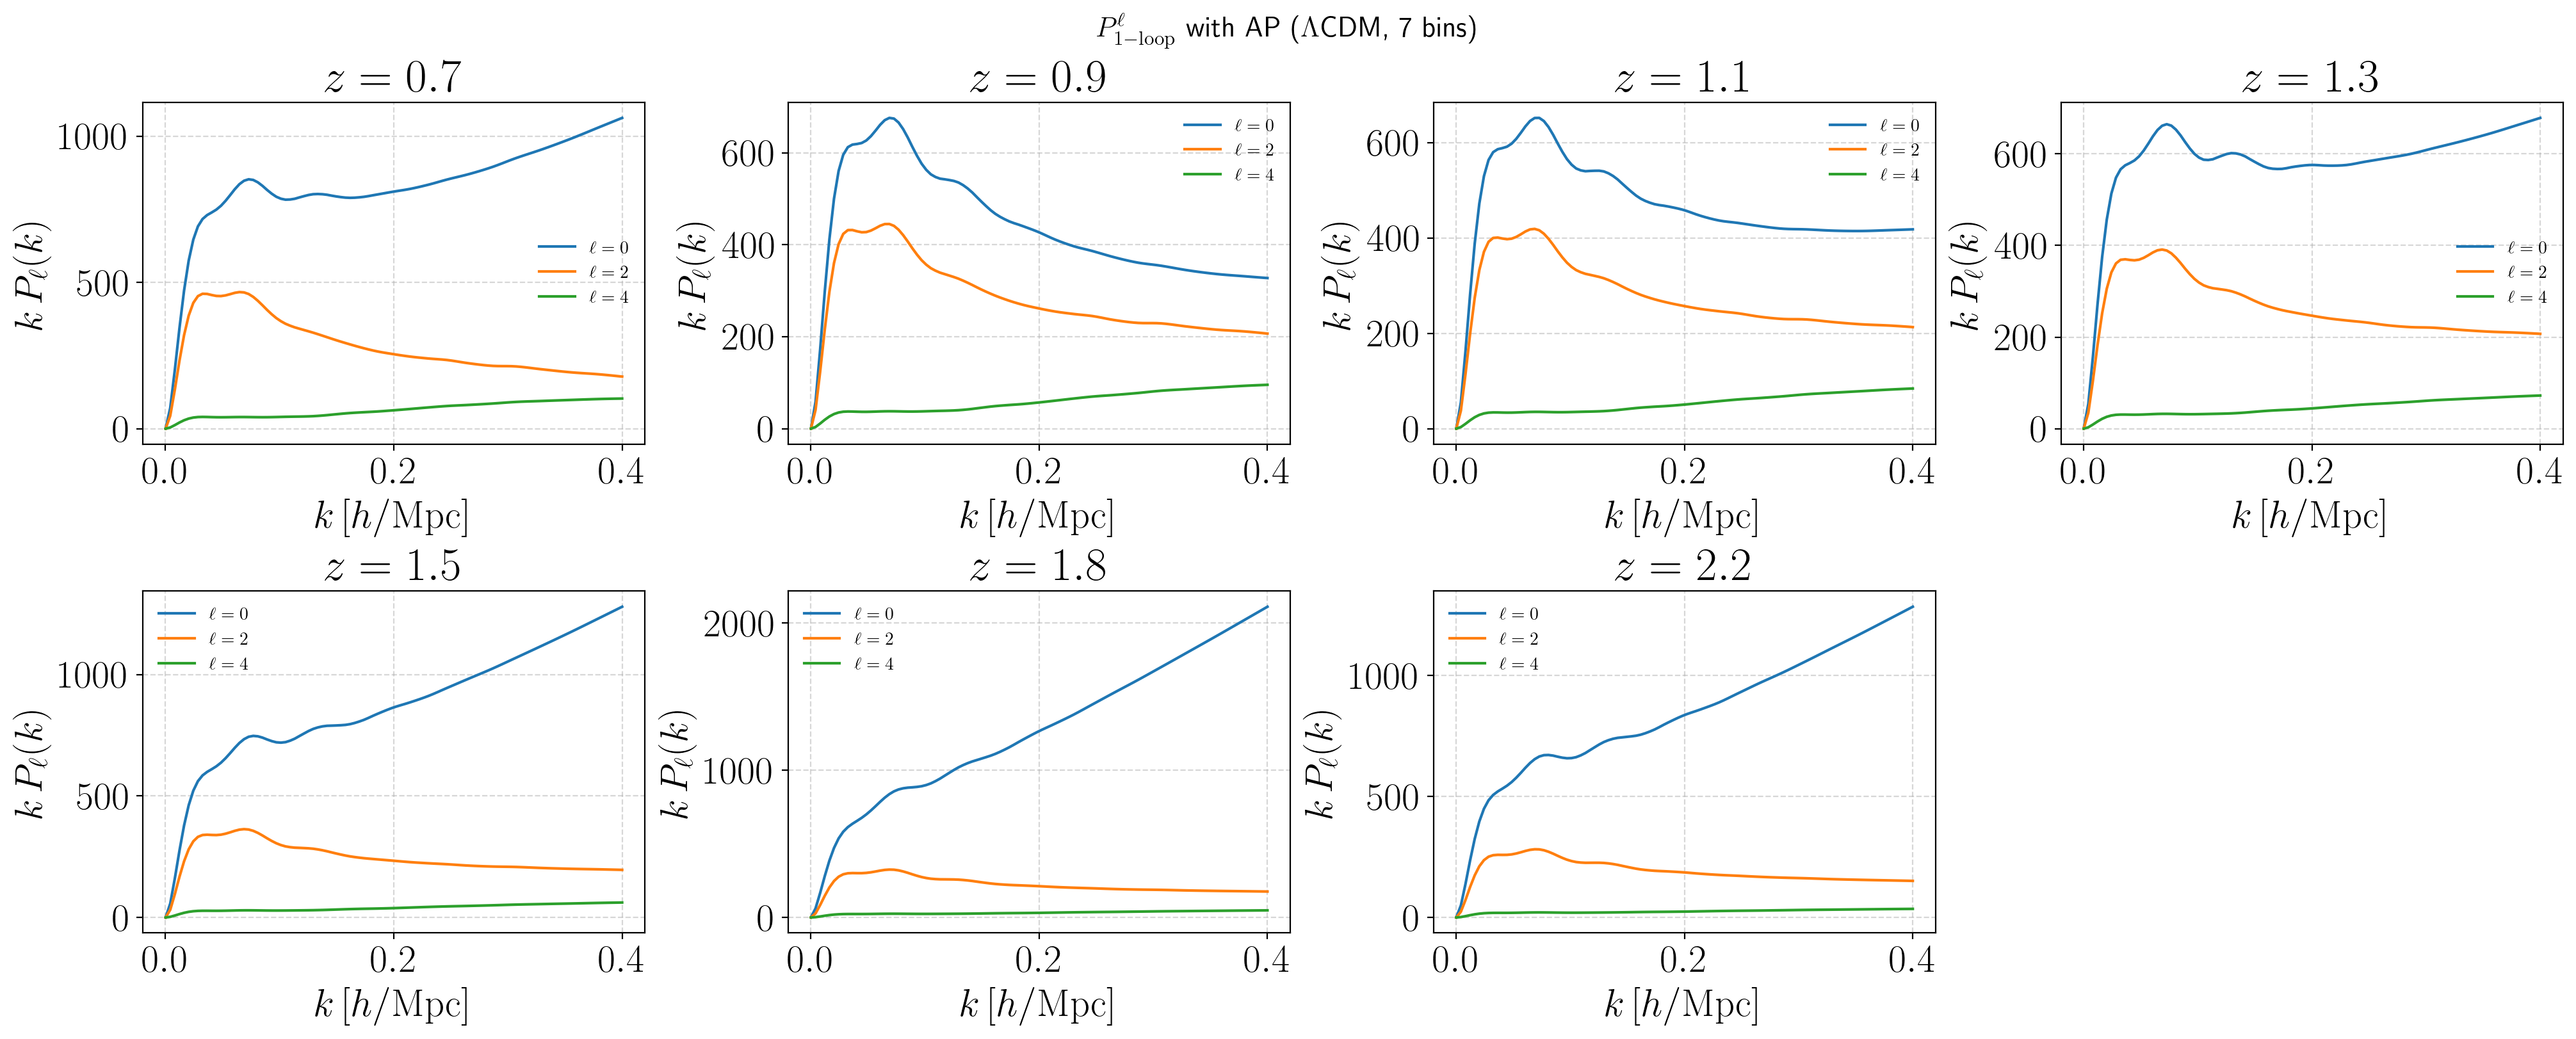

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), constrained_layout=True)
axes = axes.flatten()

for b in range(n_zbins):
    ax = axes[b]
    for l, ell in enumerate(ells_tuple):
        ax.plot(k_test, k_test * pk_all[b, l], label=r'$\ell = %d$' % ell)
    ax.set_xlabel(r'$k\,[h/\mathrm{Mpc}]$')
    ax.set_ylabel(r'$k\,P_\ell(k)$')
    ax.set_title(r'$z = %.1f$' % z_bins[b])
    ax.legend(frameon=False, fontsize=10)
    ax.grid(ls='--', alpha=0.5)

axes[-1].axis('off')
fig.suptitle(r'$P^{\ell}_{\rm 1-loop}$ with AP ($\Lambda$CDM, 7 bins)', fontsize=16)

## Jacobian

In [14]:
k = jnp.linspace(5e-3, 0.25, 50)
n_k = k.shape[0]

%time jac = jax.jacfwd(jitted_wrapper, argnums=0)(packed_params, k=k)
print(f"Jacobian shape: {jac.shape}")
print(f"  rows = {n_zbins} bins x {n_ell} ell x {n_k} k = {n_zbins * n_ell * n_k}")
print(f"  cols = {packed_params.shape[0]} parameters")

CPU times: user 8min 2s, sys: 8.69 s, total: 8min 10s
Wall time: 1min
Jacobian shape: (1050, 100)
  rows = 7 bins x 3 ell x 50 k = 1050
  cols = 100 parameters


### Jacobian sanity check: $\partial P_0 / \partial \theta$ for cosmo parameters across bins

Text(0.5, 0.98, '$\\partial P_0 / \\partial \\theta$ across bins ($\\Lambda$CDM with AP)')

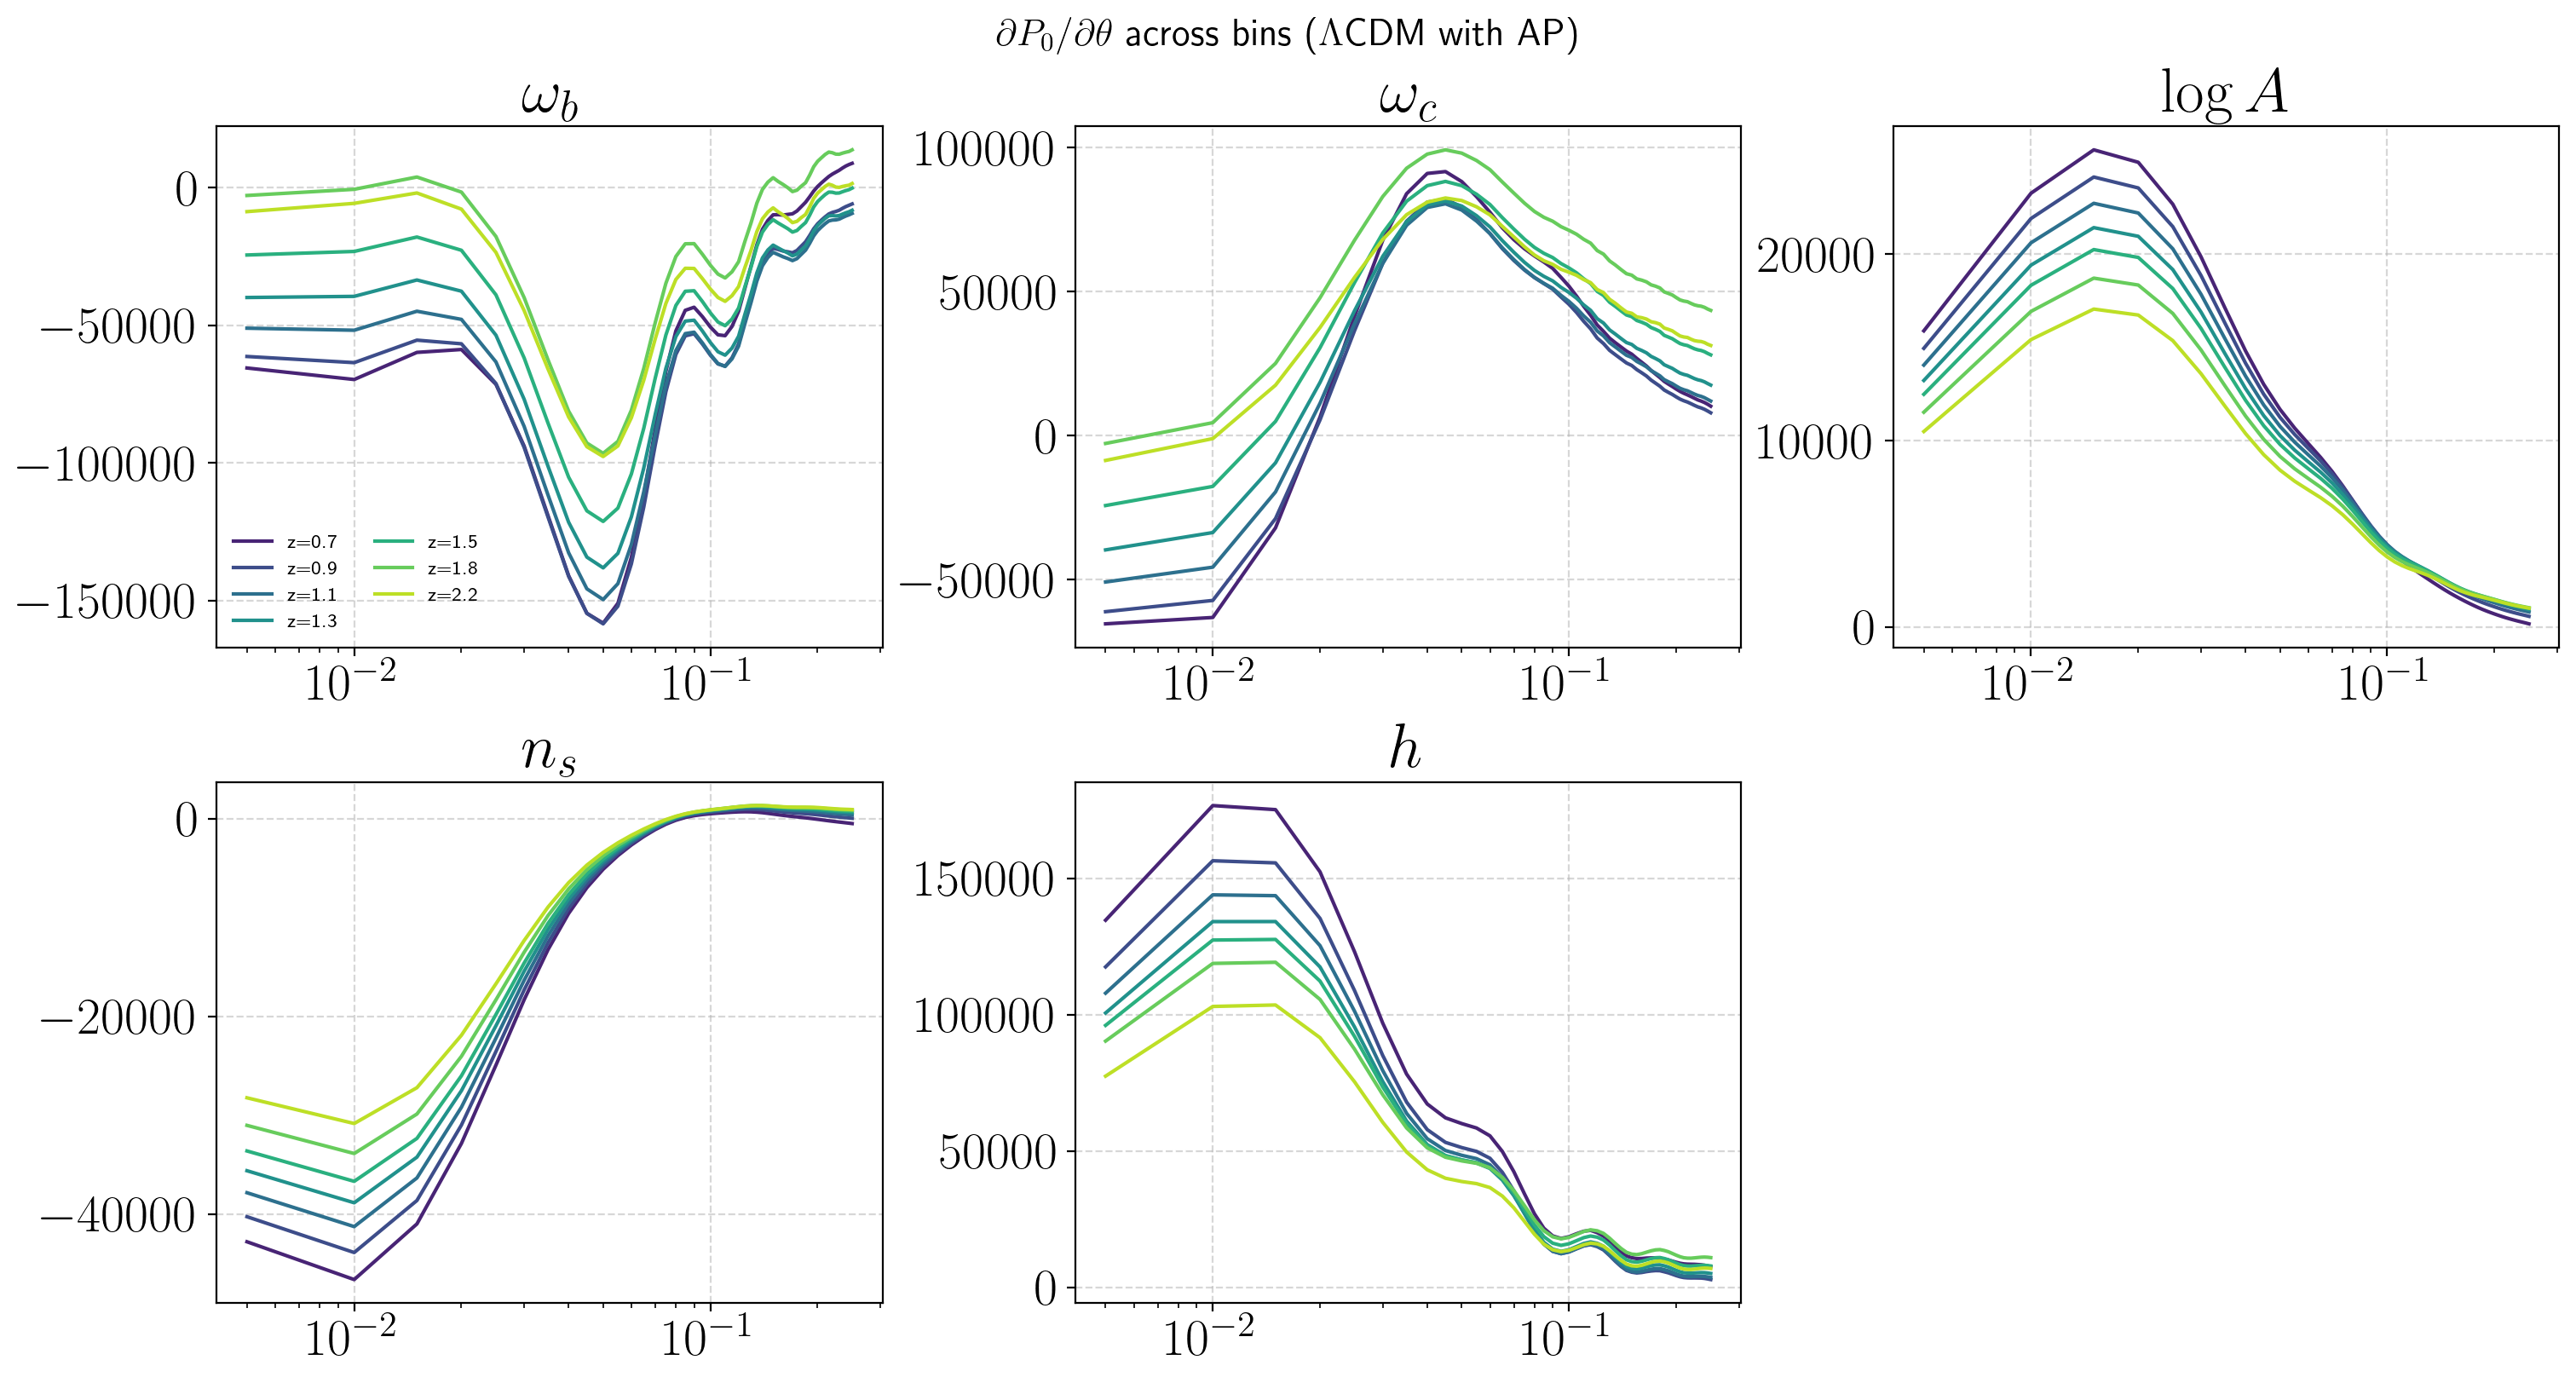

In [15]:
cosmo_labels = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$')
cosmo_idx    = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, n_zbins))

for idx, ax in enumerate(axes.flatten()):
    if idx >= len(cosmo_labels):
        ax.axis('off')
        continue
    ci = cosmo_idx[idx]
    for b in range(n_zbins):
        row_start = b * n_ell * n_k  # P0 is the first multipole block
        ax.semilogx(k, jac[row_start:row_start + n_k, ci],
                    color=colors[b], label=f'z={z_bins[b]}')
    ax.set_title(cosmo_labels[idx])
    ax.grid(ls='--', alpha=0.5)
    if idx == 0:
        ax.legend(fontsize=8, frameon=False, ncol=2)

fig.suptitle(r'$\partial P_0 / \partial \theta$ across bins ($\Lambda$CDM with AP)', fontsize=16)

## Gaussian covariance (block-diagonal across bins)

In [16]:
from jax.scipy.linalg import block_diag
# gaussian_covariance imported from jaxptpolypol.covariance

In [17]:
pk_all_fisher = jitted_wrapper(packed_params, k=k).reshape(n_zbins, n_ell, n_k)
dk = k[1] - k[0]

cov_blocks = []
for b in range(n_zbins):
    P0, P2, P4 = pk_all_fisher[b]
    cov_b = gaussian_covariance(V_bins[b], k, dk, P0, P2, P4)
    cov_blocks.append(cov_b)
    print(f"Bin {b+1} (z={z_bins[b]}): cov shape = {cov_b.shape}")

gauss_cov = block_diag(*cov_blocks)
print(f"\nFull covariance shape: {gauss_cov.shape}")

Bin 1 (z=0.7): cov shape = (150, 150)
Bin 2 (z=0.9): cov shape = (150, 150)
Bin 3 (z=1.1): cov shape = (150, 150)
Bin 4 (z=1.3): cov shape = (150, 150)
Bin 5 (z=1.5): cov shape = (150, 150)
Bin 6 (z=1.8): cov shape = (150, 150)
Bin 7 (z=2.2): cov shape = (150, 150)

Full covariance shape: (1050, 1050)


## Fisher matrix

In [18]:
# fisher_matrix imported from jaxptpolypol.inference

fisher = fisher_matrix(gauss_cov, jac)
print(f"Fisher matrix shape: {fisher.shape}")

Fisher matrix shape: (100, 100)


## DESI DR2 BAO likelihood and external priors

In [19]:
bao_data_dir = "../../ext_data/bao_data/desi_bao_dr2"
bao_dr2 = load_desi_dr2("all", data_dir=bao_data_dir)

n_cosmo_params = sum(cosmo.param_sizes)
fiducial_cosmo = packed_params[:n_cosmo_params]
F_bao = bao_fisher_matrix(
    bao_dr2,
    fiducial_cosmo,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
)

fisher_pk = fisher
fisher_pk_bao = add_bao_to_fullshape_fisher(fisher_pk, F_bao, n_cosmo=n_cosmo_params)

prior_sigmas_bbn_ns10 = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    n_bins=n_zbins,
    cosmo_priors={
        'ombh2': 0.00055,
        'ns':    0.042,
    },
)
F_prior_bbn_ns10 = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas_bbn_ns10)
fisher_pk_bao_bbn_ns10 = fisher_pk_bao + F_prior_bbn_ns10

prior_sigmas_bbn_ns = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    n_bins=n_zbins,
    cosmo_priors={
        'ombh2': 0.00055,
        'ns':    0.0042,
    },
)
F_prior_bbn_ns = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas_bbn_ns)
fisher_pk_bao_bbn_ns = fisher_pk_bao + F_prior_bbn_ns

print(f"DESI DR2 BAO data points: {len(bao_dr2.data_points)}")
print(f"BAO Fisher shape:         {F_bao.shape}")
print(f"Pk Fisher shape:          {fisher_pk.shape}")
print(f"Pk + BAO Fisher shape:    {fisher_pk_bao.shape}")
print(f"Pk + BAO + BBN + ns10:    {fisher_pk_bao_bbn_ns10.shape}")
print(f"Pk + BAO + BBN + ns:      {fisher_pk_bao_bbn_ns.shape}")
print()
print("Applied Gaussian priors:")
print("  BBN + n_{s,10}: ombh2=0.00055, ns=0.042")
print("  BBN + n_s:      ombh2=0.00055, ns=0.0042")


DESI DR2 BAO data points: 13
BAO Fisher shape:         (9, 9)
Pk Fisher shape:          (100, 100)
Pk + BAO Fisher shape:    (100, 100)
Pk + BAO + BBN + ns10:    (100, 100)
Pk + BAO + BBN + ns:      (100, 100)

Applied Gaussian priors:
  BBN + n_{s,10}: ombh2=0.00055, ns=0.042
  BBN + n_s:      ombh2=0.00055, ns=0.0042


## Marginalization

Fixed parameters (removed before inversion):
- Cosmo: `z`(5), `A_b`(6), `eta_b`(7), `logT_AGN`(8)
- Per bin: `k_nl` and `ndens` (last 2 of each 13-param survey block)

In [20]:
n_cosmo_params  = sum(cosmo.param_sizes)
n_survey_params = len(pk_survey_keys)

# Use fixed_and_varied_indices from jaxptpolypol.inference
fixed_cosmo = [5, 6, 7, 8]  # z, A_b, eta_b, logT_AGN
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]

fixed_idx, varied_idx = fixed_and_varied_indices(
    n_cosmo_params, n_survey_params, n_zbins, fixed_cosmo, fixed_survey_offsets
)

print(f"Total parameters:   {fisher_pk.shape[0]}")
print(f"Fixed parameters:   {len(fixed_idx)}  (4 cosmo + 2 x {n_zbins} bins)")
print(f"Varied parameters:  {len(varied_idx)}")

F_marg_pk = marginalize_fisher(fisher_pk, varied_idx)
F_marg_pk_bao = marginalize_fisher(fisher_pk_bao, varied_idx)
F_marg_pk_bao_bbn_ns10 = marginalize_fisher(fisher_pk_bao_bbn_ns10, varied_idx)
F_marg_pk_bao_bbn_ns = marginalize_fisher(fisher_pk_bao_bbn_ns, varied_idx)


Total parameters:   100
Fixed parameters:   18  (4 cosmo + 2 x 7 bins)
Varied parameters:  82


## Fisher contours

In [21]:
fisher_cases = [
    (r'PFS $P_k$', F_marg_pk, 'royalblue', '-'),
    (r'PFS $P_k$ + DESI DR2 BAO', F_marg_pk_bao, 'darkorange', '-.'),
    (r'$P_k$ + BAO + BBN + $n_{s,10}$', F_marg_pk_bao_bbn_ns10, 'crimson', '--'),
    (r'$P_k$ + BAO + BBN + $n_s$', F_marg_pk_bao_bbn_ns, 'forestgreen', ':'),
]

Text(0.5, 0.98, '$\\Lambda$CDM with AP: PFS $P_k$, + DESI DR2 BAO, + BBN + $n_{s,10}$, + BBN + $n_s$')

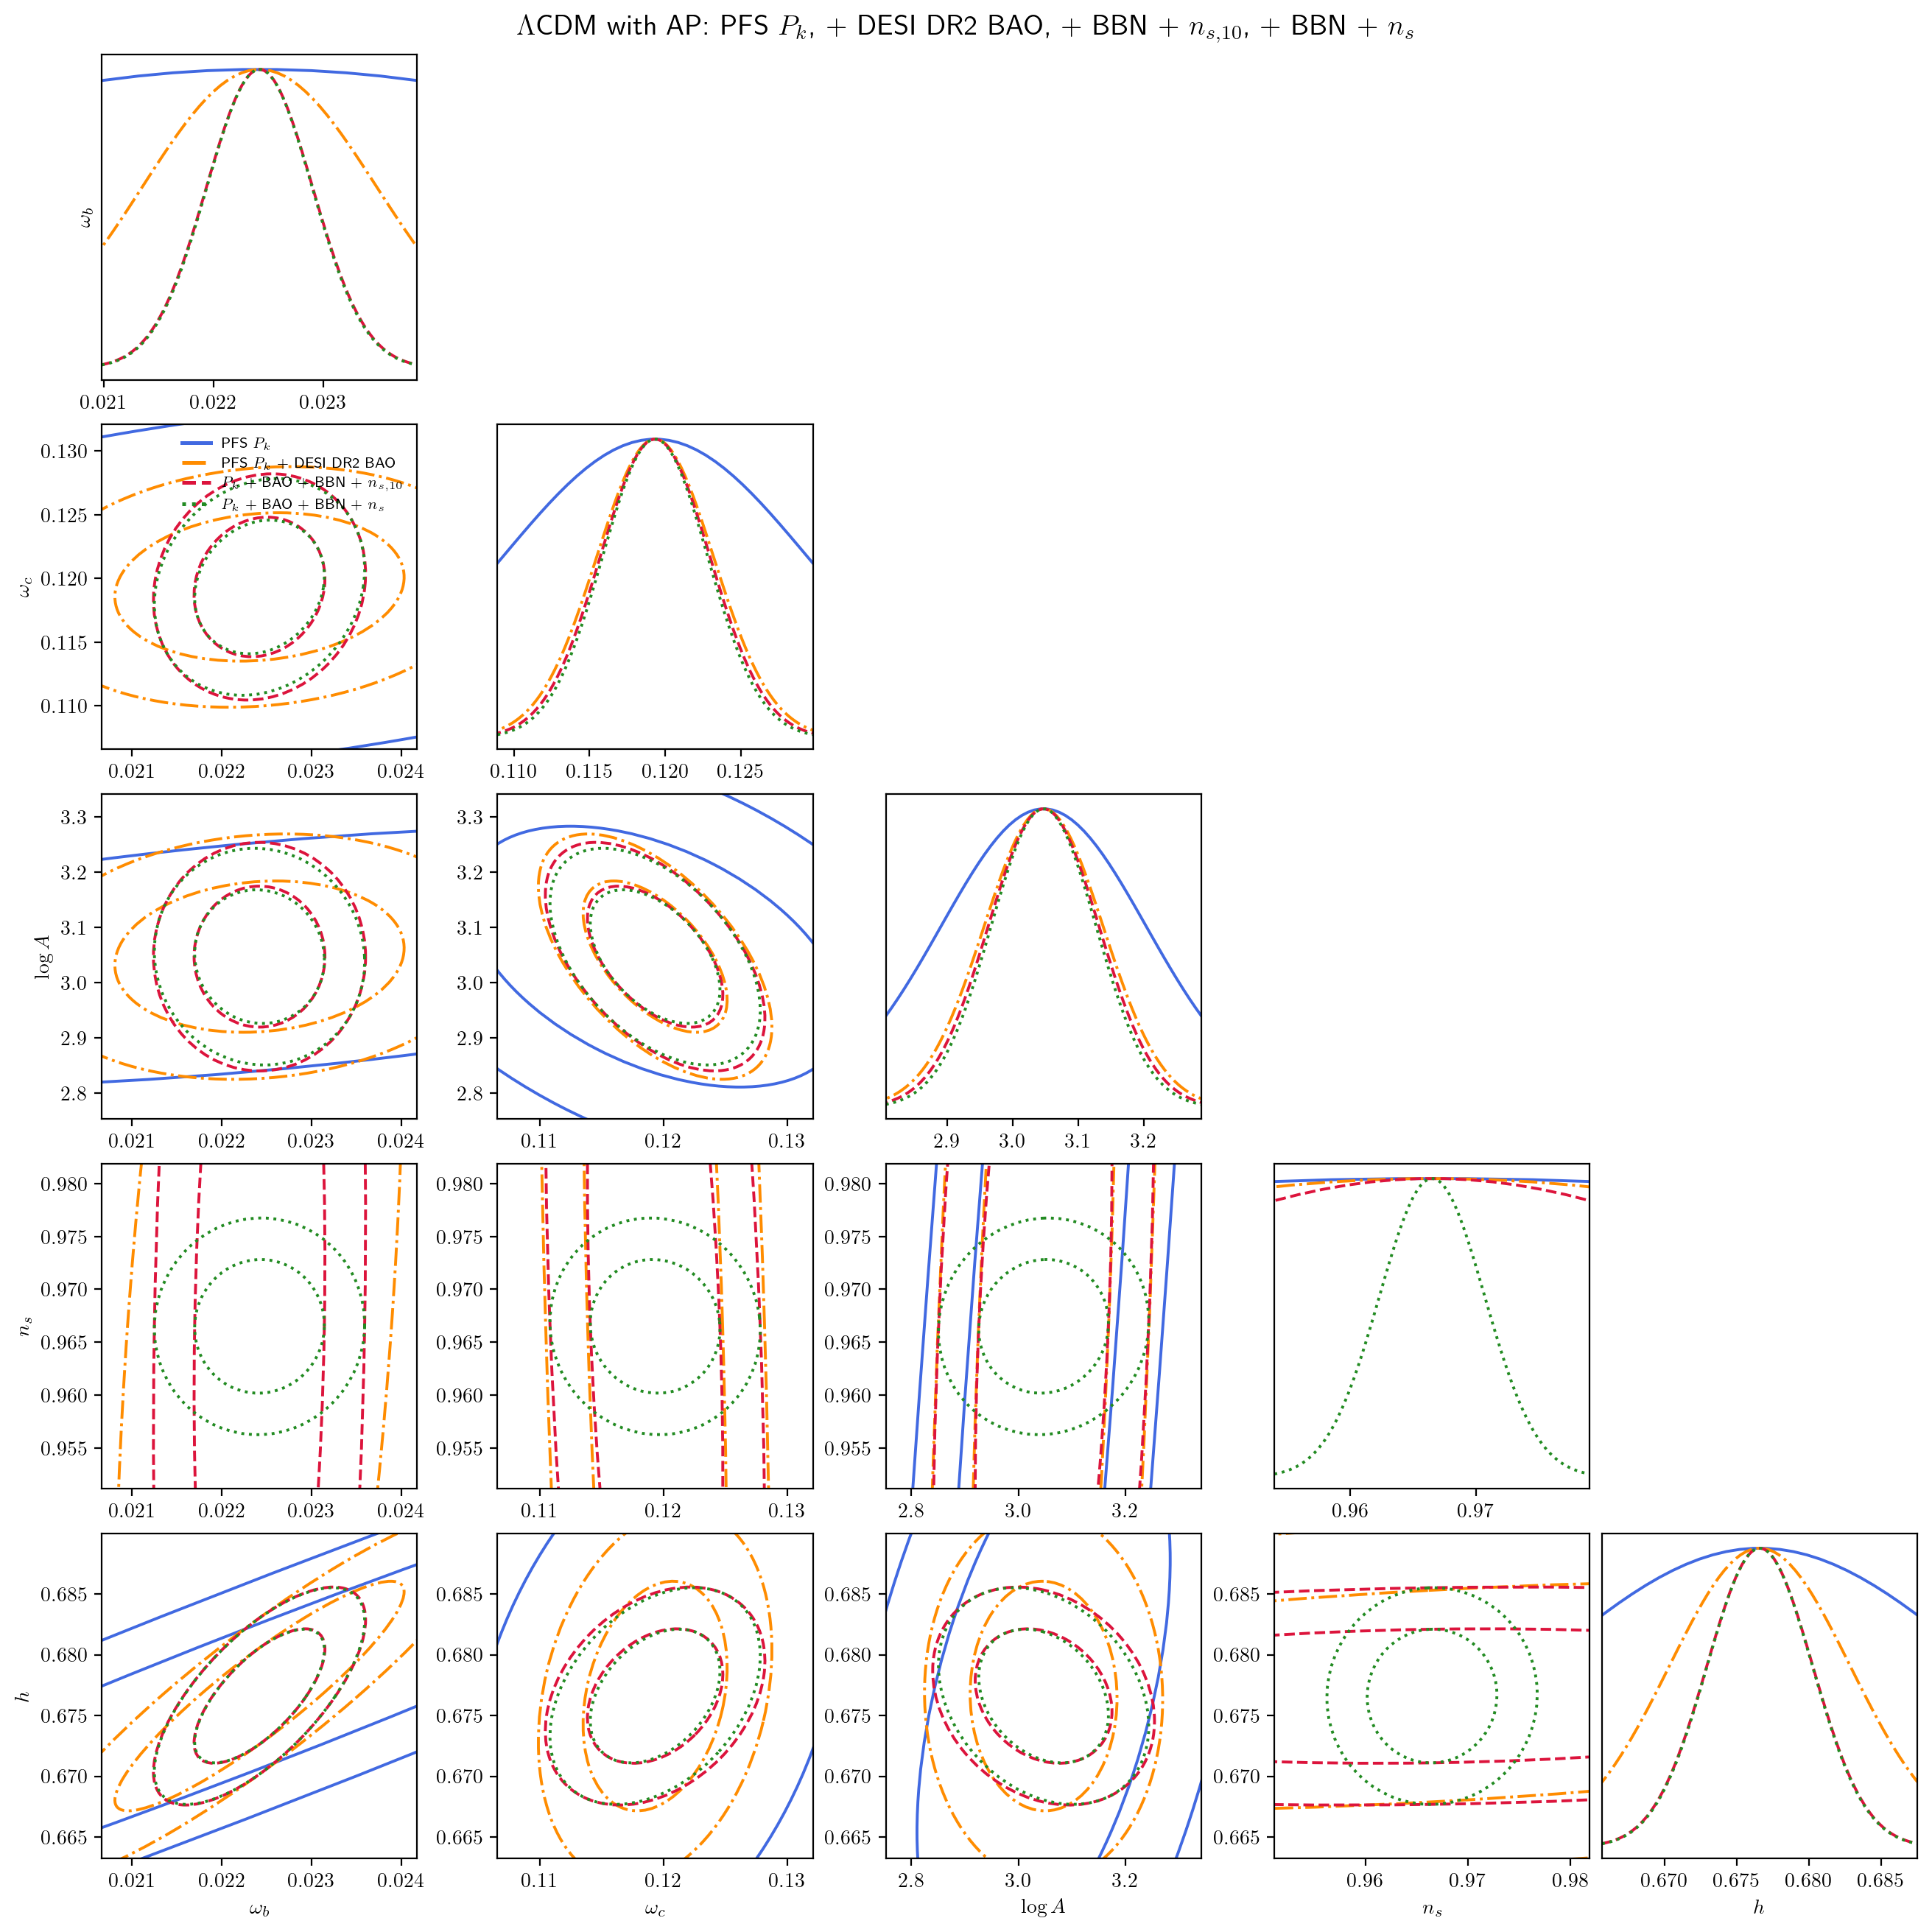

In [22]:
# Cosmo parameters to plot (no mnu in LCDM)
cosmo_param_names = (
    r'$\omega_b$', r'$\omega_c$', r'$\log A$',
    r'$n_s$', r'$h$'
)
cosmo_plot_idx_global = np.array([0, 1, 2, 3, 4])  # indices in full param vector

# Map to positions in the marginalized Fisher matrix
cosmo_marg_idx = np.array([varied_idx.index(i) for i in cosmo_plot_idx_global])
n_cosmo_plot = len(cosmo_param_names)

# Fiducial values (in the varied subspace)
packed_varied = packed_params[np.array(varied_idx)]

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(n_cosmo_plot*2.6, n_cosmo_plot*2.6), constrained_layout=True)

legend_handles = [
    mlines.Line2D([], [], color=color, ls=ls, lw=1.8, label=label)
    for label, _, color, ls in fisher_cases
]

for i in range(n_cosmo_plot):
    for j in range(n_cosmo_plot):
        ax = plt.subplot(n_cosmo_plot, n_cosmo_plot, i*n_cosmo_plot+j+1)
        if j < i:
            for _, fisher_case, color, ls in fisher_cases:
                plot_contours(
                    fisher_case,
                    packed_varied,
                    np.array([cosmo_marg_idx[j], cosmo_marg_idx[i]]),
                    ax=ax,
                    fill=False,
                    color=color,
                    ls=ls,
                    lw=1.4,
                cls=[0.68, 0.95], level_kind="mass2d")
            if i == 1 and j == 0:
                ax.legend(handles=legend_handles, fontsize=7, frameon=False, loc='best')
        elif j == i:
            for _, fisher_case, color, ls in fisher_cases:
                plot_Gaussian(
                    fisher_case,
                    packed_varied,
                    cosmo_marg_idx[i],
                    ax=ax,
                    color=color,
                    ls=ls,
                    lw=1.4,
                )
            ax.set_yticks([])
        else:
            ax.axis('off')
        if i == n_cosmo_plot - 1:
            plt.xlabel(cosmo_param_names[j])
        if j == 0:
            plt.ylabel(cosmo_param_names[i])

fig.suptitle(r'$\Lambda$CDM with AP: PFS $P_k$, + DESI DR2 BAO, + BBN + $n_{s,10}$, + BBN + $n_s$', fontsize=14)

## Marginalized 1$\sigma$ constraints

In [23]:
from jax.scipy.linalg import inv
from jaxptpolypol.chain_analysis import make_fullshape_spec

spec = make_fullshape_spec(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    n_bins=n_zbins,
    varied_idx=varied_idx,
    analysis_kind='pk',
)
varied_names = list(spec.varied_param_names())

sigma_pk = jnp.sqrt(jnp.diag(inv(F_marg_pk)))
sigma_pk_bao = jnp.sqrt(jnp.diag(inv(F_marg_pk_bao)))
sigma_pk_bao_bbn_ns10 = jnp.sqrt(jnp.diag(inv(F_marg_pk_bao_bbn_ns10)))
sigma_pk_bao_bbn_ns = jnp.sqrt(jnp.diag(inv(F_marg_pk_bao_bbn_ns)))

print("Marginalized 1-sigma constraints (LCDM, 7 PFS bins)")
print("=" * 120)
print(f"{'Parameter':>25s}  {'Fiducial':>10s}  {'PFS Pk':>12s}  {'Pk + BAO':>12s}  {'+ BBN+ns10':>12s}  {'+ BBN+ns':>12s}")
print("-" * 120)

print("\nCosmological parameters:")
for name, midx in zip(cosmo_param_names, cosmo_marg_idx):
    fid = float(packed_varied[midx])
    s_pk = float(sigma_pk[midx])
    s_pk_bao = float(sigma_pk_bao[midx])
    s_ns10 = float(sigma_pk_bao_bbn_ns10[midx])
    s_ns = float(sigma_pk_bao_bbn_ns[midx])
    print(f"  {name:23s}  {fid:10.5g}  {s_pk:12.5g}  {s_pk_bao:12.5g}  {s_ns10:12.5g}  {s_ns:12.5g}")

print("\nAll varied parameters (Pk + BAO + BBN + ns):")
for i, name in enumerate(varied_names):
    fid = float(packed_varied[i])
    sp = float(sigma_pk_bao_bbn_ns[i])
    print(f"  {name:30s}:  fid = {fid:12.5g},  sigma = {sp:12.5g}")


Marginalized 1-sigma constraints (LCDM, 7 PFS bins)
                Parameter    Fiducial        PFS Pk      Pk + BAO    + BBN+ns10      + BBN+ns
------------------------------------------------------------------------------------------------------------------------

Cosmological parameters:
  $\omega_b$                  0.02242      0.005203     0.0010685    0.00048329    0.00047914
  $\omega_c$                  0.11933      0.010061     0.0038573     0.0036269     0.0034737
  $\log A$                      3.047       0.15655      0.090805      0.084577      0.080189
  $n_s$                        0.9665      0.088268      0.052816      0.031945     0.0041848
  $h$                          0.6766      0.015327     0.0062558     0.0036638     0.0036413

All varied parameters (Pk + BAO + BBN + ns):
  ombh2                         :  fid =      0.02242,  sigma =   0.00047914
  omch2                         :  fid =      0.11933,  sigma =    0.0034737
  logA                          :  fi

In [24]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

native_cosmo_keys = tuple(cosmo.param_keys[int(i)] for i in cosmo_plot_idx_global)
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
)

projection_cases = [
    {'label': 'PFS Pk', 'fisher': F_marg_pk, 'packed_varied': packed_varied, 'cosmo_marg_idx': cosmo_marg_idx},
    {'label': 'Pk+BAO', 'fisher': F_marg_pk_bao, 'packed_varied': packed_varied, 'cosmo_marg_idx': cosmo_marg_idx},
    {'label': 'Pk+BAO+BBN+ns10', 'fisher': F_marg_pk_bao_bbn_ns10, 'packed_varied': packed_varied, 'cosmo_marg_idx': cosmo_marg_idx},
    {'label': 'Pk+BAO+BBN+ns', 'fisher': F_marg_pk_bao_bbn_ns, 'packed_varied': packed_varied, 'cosmo_marg_idx': cosmo_marg_idx},
]

selected_fisher_cases = []
for case in projection_cases:
    projection = project_case_to_specs(
        case['fisher'],
        case['packed_varied'],
        case['cosmo_marg_idx'],
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({**case, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>18s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:18.5g}" if np.isfinite(sigma) else f"  {'---':>18s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial              PFS Pk              Pk+BAO     Pk+BAO+BBN+ns10       Pk+BAO+BBN+ns
----------------------------------------------------------------------------------------------------------------
        $\Omega_m$       0.31105            0.022136           0.0081459           0.0074196           0.0069811
             $H_0$         67.66              1.5327             0.62558             0.36638             0.36413
        $\sigma_8$       0.81038            0.055939            0.037924            0.032321            0.028202
